In [1]:
#Load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

import numpy as np

import seaborn as sb
sb.set_style('whitegrid')


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

from sklearn.model_selection import train_test_split

SEED = 42

pd.options.display.max_columns = None
pd.set_option('display.max_rows', 50)
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.python.client import device_lib

import keras as keras
from keras import models
from tensorflow.keras import models

%matplotlib inline
rcParams['figure.figsize'] = 20, 16

In [2]:
tf.test.is_built_with_cuda()
tf.config.list_physical_devices('GPU')
print(device_lib.list_local_devices())
print("\n Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 17585955693954014810
xla_global_id: -1
]

 Num GPUs Available:  0


In [3]:
address = './Input/music genre.xlsx'

file_read = pd.read_excel(address)
file_read.columns = ['filename','tempo','beats','chroma_stft','rmse','spectral_centroid','spectral_bandwidth','rolloff','zero_crossing_rate','mfcc1','mfcc2','mfcc3','mfcc4','mfcc5','mfcc6','mfcc7','mfcc8','mfcc9','mfcc10','mfcc11','mfcc12','mfcc13','mfcc14','mfcc15','mfcc16','mfcc17','mfcc18','mfcc19','mfcc20','label']

In [4]:
df_music = file_read.drop(['filename'], axis=1)
df_music_2 = df_music
df_music_2['label'] = df_music_2['label'].map({'blues': 1, 'classical': 2, 'country': 3, 'disco': 4, 'hiphop': 5, 'jazz': 6, 'metal': 7, 'pop': 8, 'reggae': 9, 'rock': 10})
df_music_2 = pd.concat([df_music_2, pd.DataFrame(columns=['label'], dtype=int)], ignore_index=True)
df_music_2['label'] = df_music_2['label'].astype("category")
df_music_2['label'] = pd.to_numeric(df_music_2['label'])

In [5]:
df_music_2

,tempo,beats,chroma_stft,rmse,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,mfcc3,mfcc4,mfcc5,mfcc6,mfcc7,mfcc8,mfcc9,mfcc10,mfcc11,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,label
0,103.359375,50.0,0.380260,0.248262,2116.942959,1956.611056,4196.107960,0.127272,-26.929785,107.334008,-46.809993,40.932634,-21.463776,24.816275,-18.945571,15.253459,-15.050104,12.262823,-15.234050,14.336612,-13.821769,7.562789,-6.181372,0.330165,-6.829571,0.965922,-7.570825,2.918987,1
1,95.703125,44.0,0.306451,0.113475,1156.070496,1497.668176,2170.053545,0.058613,-233.860772,136.170239,3.289490,48.931193,8.699106,13.954752,5.359449,0.381334,-13.490265,16.871769,5.145258,-2.250578,3.959198,5.322555,0.812028,-1.107202,-4.556555,-2.436490,3.316913,-0.608485,1
2,151.999081,75.0,0.253487,0.151571,1331.073970,1973.643437,2900.174130,0.042967,-221.802549,110.843070,18.620984,30.922996,3.291330,22.587447,-20.418303,12.120995,-26.347956,-4.356270,-26.406674,-13.037723,-12.652228,-1.821905,-7.260097,-6.660252,-14.682694,-11.719264,-11.025216,-13.387260,1
3,184.570312,91.0,0.269320,0.119072,1361.045467,1567.804596,2739.625101,0.069124,-207.208080,132.799175,-15.438986,60.986727,0.725807,12.437828,1.183836,-1.540779,-17.888154,8.358496,-2.452068,-0.613248,0.384877,2.605128,-5.188924,-9.527455,-9.244394,-2.848274,-1.418707,-5.932607,1
4,161.499023,74.0,0.391059,0.137728,1811.076084,2052.332563,3927.809582,0.075480,-145.434568,102.829023,-12.517677,56.993472,2.271347,26.591402,-4.274803,17.338809,-7.985593,15.235427,-6.934599,7.457218,-10.470444,-2.360483,-6.783623,2.671134,-4.760879,-0.949005,0.024832,-2.005315,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,123.046875,59.0,0.418812,0.166056,2312.030070,2060.825761,4528.197619,0.140588,-41.402023,105.403012,-43.945538,54.100395,-18.411090,23.520838,-17.607988,20.660727,-18.454381,17.475770,-15.174259,11.303100,-14.155566,2.824157,-9.477822,3.331261,-8.200088,3.693091,-3.673562,-0.163201,10
996,117.453835,56.0,0.335774,0.093676,2553.856706,2219.090892,5123.752351,0.136173,-121.410791,89.522283,-33.497073,41.974745,-25.936361,23.026082,-20.271538,14.354429,-16.350707,17.039462,-16.957086,9.149520,-10.112054,4.211237,-9.349345,1.609701,-10.553566,1.066489,-1.654875,7.544224,10
997,103.359375,45.0,0.372834,0.208743,1345.850763,1841.748033,2939.265560,0.041099,-127.946876,134.443879,1.027332,54.440979,-0.464906,35.829542,-10.860896,16.383278,-10.030961,6.602061,-6.700004,11.043714,-8.385375,2.111019,-6.338260,0.997383,-5.325869,-0.842192,-4.665996,-4.787677,10
998,112.347147,45.0,0.344472,0.180163,1675.475369,1653.422860,3253.563659,0.087294,-98.356322,136.611573,-46.700574,46.457300,-17.135585,10.505286,-14.554871,16.543108,-12.317913,3.689543,-12.647550,2.945863,-12.509212,0.091337,-0.774780,-5.700102,-8.630916,-1.903803,-2.196753,-3.395148,10


In [6]:
X, y = df_music_2.drop(['label'], axis=1), df_music_2['label']
print('X', X.shape, 'y', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=SEED)
print('X_train', X_train.shape)
print('y_train', y_train.shape)
print('X_test', X_test.shape)
print('y_test', y_test.shape)

X (1000, 28) y (1000,)
X_train (750, 28)
y_train (750,)
X_test (250, 28)
y_test (250,)


In [7]:
#model = keras.models.load_model('C:/Users/nyx3t/OneDrive/Desktop/Music Genre/Input/keras_models/music_genre', compile=True)

model = models.Sequential()

optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001,beta_1=0.9, beta_2=0.999,epsilon=1e-07,name="Adamax")

model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Dense(1000, activation='relu',trainable=True, input_shape=(X_train.shape[1],)))
#model.add(keras.layers.LayerNormalization(epsilon=0.001))

model.add(keras.layers.Dense(500, activation='relu', trainable=True,))
#model.add(keras.layers.LayerNormalization(epsilon=0.001))

model.add(keras.layers.Dense(250, activation='relu',trainable=True,))
model.add(keras.layers.LayerNormalization(epsilon=0.001))

model.add(keras.layers.Dense(11,trainable=True, activation='softmax'))

model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'],run_eagerly=True)

In [8]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy',mode='max',patience=60, restore_best_weights=True)

history = model.fit(X_train,y_train, epochs = 300, 
                    callbacks=[early_stopping], 
                    verbose=1, 
                    #workers=12,
                    #use_multiprocessing=True, 
                    validation_data=(X_test,y_test), 
                    steps_per_epoch=256, 
                    batch_size=500, 
                    #max_queue_size=10
                    )

Epoch 1/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.1800 - loss: 2.8209 - val_accuracy: 0.2000 - val_loss: 2.3418
Epoch 2/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step - accuracy: 0.5027 - loss: 1.5706 - val_accuracy: 0.1680 - val_loss: 2.1813
Epoch 3/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 255us/step - accuracy: 0.5720 - loss: 1.2189 - val_accuracy: 0.2000 - val_loss: 2.0748
Epoch 4/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 267us/step - accuracy: 0.5813 - loss: 1.1454 - val_accuracy: 0.2480 - val_loss: 2.0389
Epoch 5/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 288us/step - accuracy: 0.6600 - loss: 0.9929 - val_accuracy: 0.2800 - val_loss: 2.0666
Epoch 6/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step - accuracy: 0.7133 - loss: 0.9022 - val_accuracy: 0.3520 - val_loss: 2.0909
Epoch 7/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step - accuracy: 0.7373 - loss: 0.8464 - val_accuracy: 0.3920 - val_loss: 2.0011
Epoch 8/300
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step - accuracy: 0.7640 - loss: 0

In [9]:
val_loss, val_accuracy  = model.evaluate(X_test, y_test)
print('Loss = ',val_loss,'\nAccuracy = ',val_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7200 - loss: 1.2903 
Loss =  1.2903409004211426 
Accuracy =  0.7200000286102295


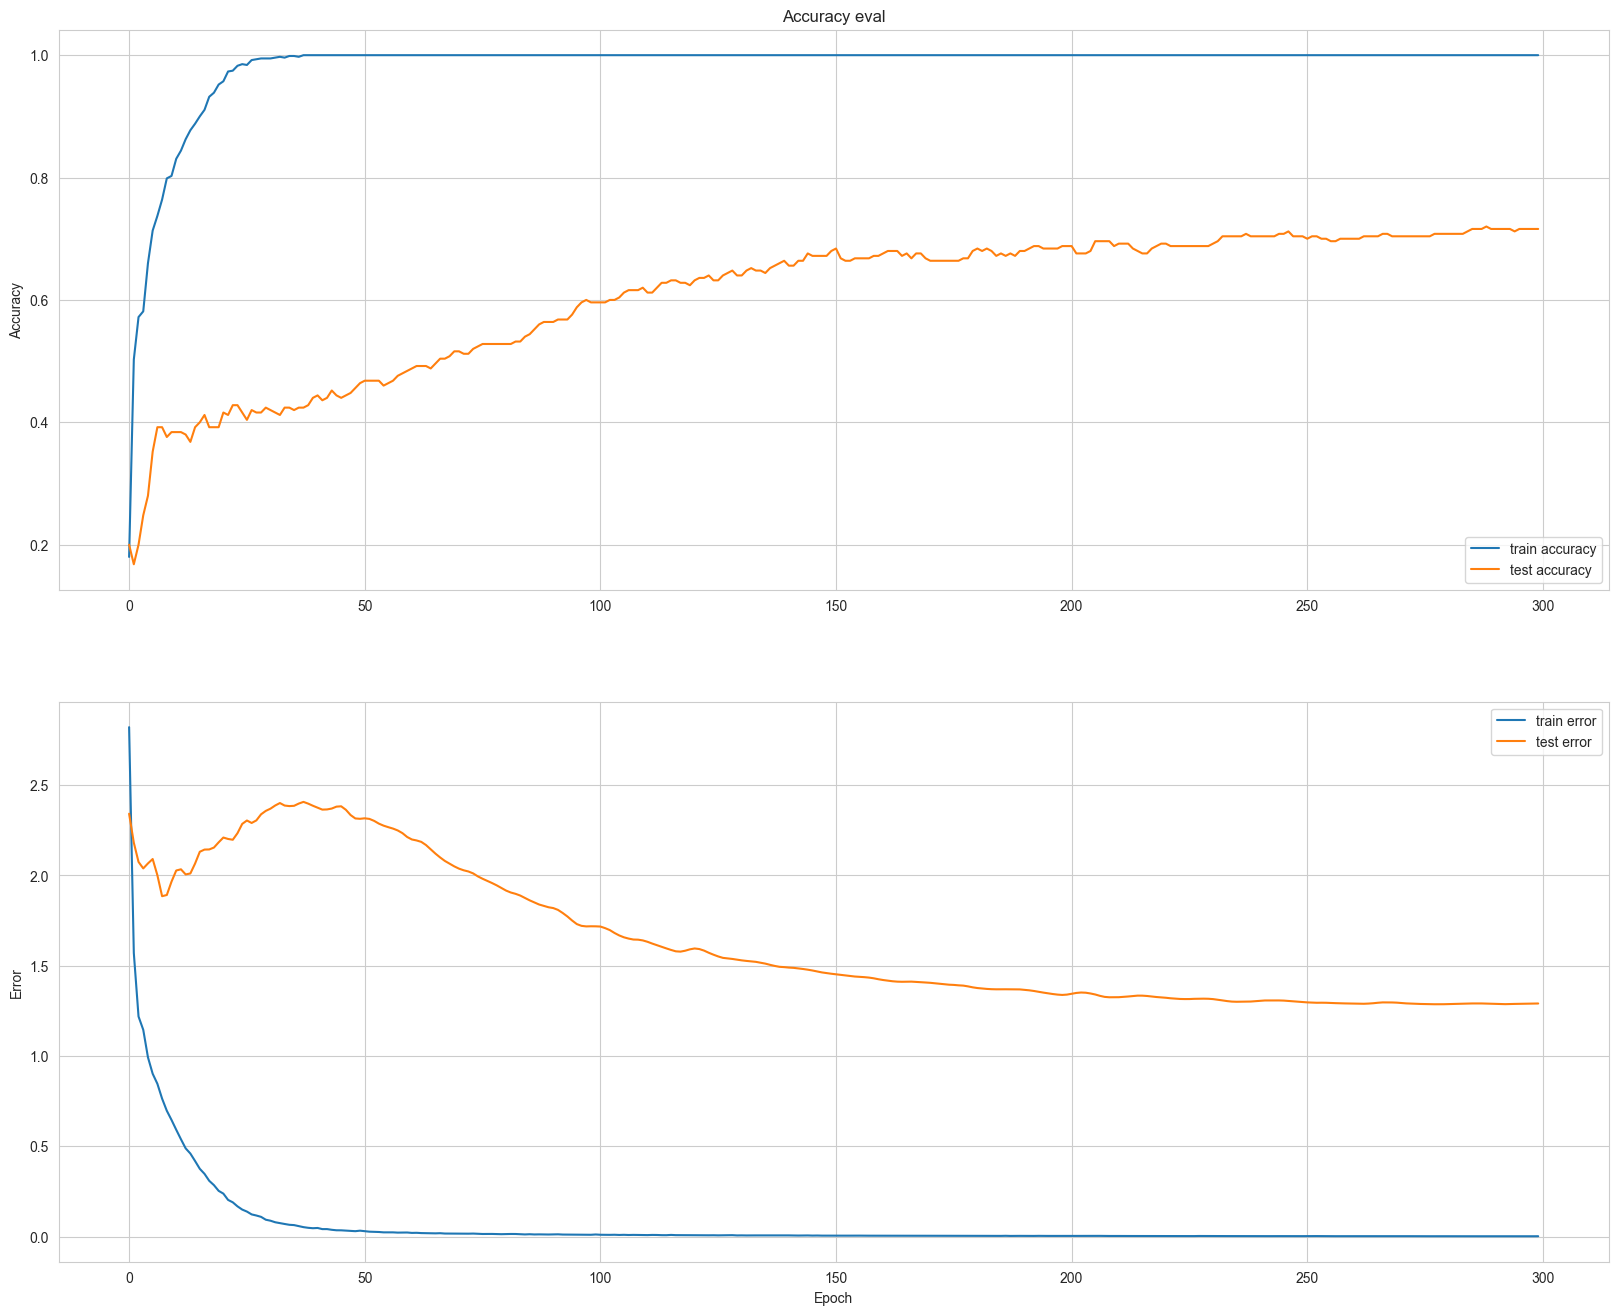

In [10]:
fig,axs = plt.subplots(2)
axs[0].plot(history.history["accuracy"],label="train accuracy")
axs[0].plot(history.history["val_accuracy"],label="test accuracy")
axs[0].set_ylabel("Accuracy")
axs[0].legend(loc='lower right')
axs[0].set_title("Accuracy eval")
    
axs[1].plot(history.history["loss"],label="train error")
axs[1].plot(history.history["val_loss"],label="test error")
axs[1].set_ylabel("Error")
axs[1].set_xlabel("Epoch")
axs[1].legend(loc='upper right')
plt.show()

In [11]:
model.save("./Input/keras_models/music_genre", overwrite=True, include_optimizer=True,save_traces=True)
model.summary()

ValueError: The following argument(s) are not supported: ['save_traces']

In [ ]:
prediction = model.predict(X_test)
predicted_index = np.argmax(prediction, axis=1)
prediction

In [ ]:
y_pred = pd.DataFrame(predicted_index,index=X_test.index, columns=['label predicted'])
pred_results = pd.merge(y_test,y_pred,right_index=True, left_index=True)
pred_results['label'] = pred_results['label'].map({ 1: 'blues', 2 : 'classical', 3 : 'country', 4 : 'disco', 5 : 'hiphop',6 : 'jazz', 7 : 'metal', 8 : 'pop', 9 : 'reggae', 10 : 'rock' })
pred_results['label predicted'] = pred_results['label predicted'].map({ 1: 'blues', 2 : 'classical', 3 : 'country', 4 : 'disco', 5 : 'hiphop',6 : 'jazz', 7 : 'metal', 8 : 'pop', 9 : 'reggae', 10 : 'rock' })

pred_results

In [ ]:
pred_results_csv = pd.merge(X_test,pred_results,right_index=True, left_index=True)
pred_results_csv.to_csv (r'./Output/music_results_keras.csv', index = True, header=True)
pred_results_csv